# PGSTE and longitudinal (T1) relaxation: the mixing time gates surface relaxivity

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dmrai-lab/dmipy-fit/blob/main/examples/11_acquisition_families/pgste_t1_relaxation.ipynb)

A **pulsed-gradient stimulated echo** (PGSTE) splits the diffusion encoding around a *mixing
time* $\mathrm{TM}$ during which the magnetisation is parked along the main field. While it is
stored longitudinally it does **not** dephase and does **not** feel the walls: transverse
relaxation ($T_2$) and surface relaxivity are switched off, and only longitudinal relaxation
($T_1$) acts. This is what lets PGSTE reach long diffusion times $\Delta$ without paying the
$T_2$ penalty a matched PGSE would.

dmipy models this as a composable, occupancy-gated factor. The transverse factors already
present —
[`TransverseRelaxation`](../../dmipy_fit/signal_models/attenuation.py) ($\exp(-\tau_\perp/T_2)$)
and `SurfaceRelaxivity` — are gated by the transverse occupancy (the echo time). The new
[`LongitudinalRelaxation`](../../dmipy_fit/signal_models/attenuation.py) factor is their
longitudinal sibling, $\exp(-\tau_\parallel/T_1)$ with $\tau_\parallel=\mathrm{TM}$. It is
**inert on a plain spin echo** (no mixing time) and activates only when the acquisition scheme
carries a `TM` — which `AcquisitionScheme.from_pgste` sets.

> Note on the stimulated echo's constant $\tfrac12$ amplitude: on the fit path it is a global
> constant on every PGSTE measurement, degenerate with the overall signal scale `S0_global`, so
> it is **absorbed by the global signal scale** and no such factor is applied here — it changes
> no fitted parameter.

In [1]:
# On Colab this installs the engines (public on GitHub); locally it is a no-op.
import importlib.util, subprocess, sys
if importlib.util.find_spec("dmipy_fit") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "dmipy-sim @ git+https://github.com/dmrai-lab/dmipy-sim.git",
                    "dmipy-fit @ git+https://github.com/dmrai-lab/dmipy-fit.git"], check=True)

## A PGSTE scheme carries the mixing time

`from_pgste(bvalues, directions, delta, TM)` builds the stimulated-echo encoding: the effective
pulse separation is $\Delta=\delta+\mathrm{TM}$ (the diffusion time spans the storage), the
transverse echo time defaults to $2\delta$ (only the two encoding lobes are transverse), and the
scheme carries `TM`.

In [2]:
import numpy as np
from dmipy_fit.core.acquisition_scheme import AcquisitionScheme

bvals = np.array([0., 1e9, 2e9, 3e9])          # s/m^2  (1e9 = 1000 s/mm^2)
dirs = np.array([[0, 0, 1.], [1, 0, 0], [0, 1, 0], [0, 0, 1.]])
delta, TM = 6e-3, 50e-3                          # 6 ms encoding, 50 ms storage

pgste = AcquisitionScheme.from_pgste(bvals, dirs, delta=delta, TM=TM)
print("TM    =", np.unique(pgste.TM), "s")
print("Delta =", np.unique(pgste.Delta), "s   (= delta + TM)")
print("TE    =", np.unique(pgste.TE), "s   (= 2*delta, transverse only)")

/home/rutger/dmrai-ws/dmipy-fit/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TM    = [0.05] s
Delta = [0.056] s   (= delta + TM)
TE    = [0.012] s   (= 2*delta, transverse only)


## Forward signal with the T1 factor

We layer the occupancy-gated factors onto a single stick compartment: transverse relaxation,
surface relaxivity, and the new longitudinal factor. On the PGSTE scheme all three are active;
on a spin echo the longitudinal factor is the identity.

In [3]:
from dmipy_fit.signal_models.cylinder_models import C1Stick
from dmipy_fit.signal_models.attenuation import (
    OccupancyGatedModel, TransverseRelaxation, SurfaceRelaxivity,
    LongitudinalRelaxation)

# S/V = 4/d for a d = 2 um pore; rho = surface relaxivity (m/s)
compartment = OccupancyGatedModel(C1Stick(), [
    SurfaceRelaxivity(surface_to_volume=4.0 / 2e-6),
    TransverseRelaxation(),
    LongitudinalRelaxation(),
])
params = dict(mu=[0., 0.], lambda_par=1.7e-9,
              surface_relaxivity=10e-6, T2=0.06, T1=1.1)

E_pgste = np.asarray(compartment(pgste, **params))
print("PGSTE signal:", np.round(E_pgste, 4))

# A plain spin echo (from_pgse) has no TM -> the longitudinal factor drops out (== 1)
pgse = AcquisitionScheme.from_pgse(bvals, dirs, delta=delta, Delta=delta + TM,
                                   TE=2 * delta + TM)
E_pgse = np.asarray(compartment(pgse, **params))
print("PGSE  signal:", np.round(E_pgse, 4))

PGSTE signal: [0.6154 0.6154 0.6154 0.0036]
PGSE  signal: [0.103  0.103  0.103  0.0006]


## The mixing time gates surface relaxivity and T2

Here is the whole point. We sweep the diffusion time by lengthening the storage/separation and
plot the $b=0$ relaxation weight for two matched acquisitions:

- **PGSE** — the magnetisation is *transverse* the whole time, so $T_2$ **and** surface
  relaxivity accrue over the full echo time $2\delta+t$.
- **PGSTE** — only the two $\delta$ lobes are transverse ($T_2$ + surface over $2\delta$); the
  storage window $t$ costs only $T_1$.

Because $T_1\gg T_2$ and surface relaxivity is switched off during storage, PGSTE retains far
more signal at long diffusion times — this gap *is* the gating.

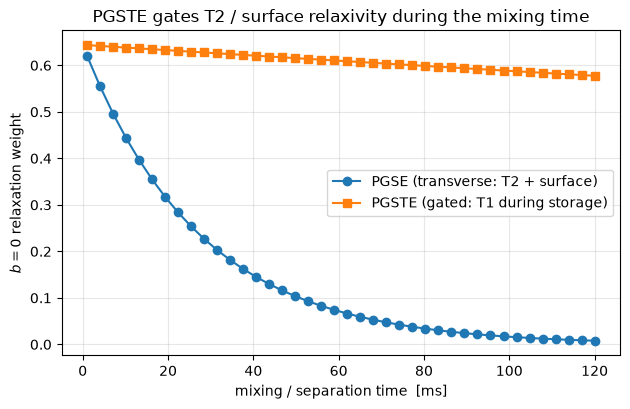

gap at t=1 ms : 0.0226
gap at t=120 ms: 0.5696


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

storage = np.linspace(1e-3, 120e-3, 40)          # sweep the mixing / separation time
b0dir = np.array([[0., 0., 1.]])
b0 = np.array([0.])

def b0_weight(scheme):
    """b=0 signal = the pure relaxation/surface weight (no diffusion attenuation)."""
    return float(np.asarray(compartment(scheme, **params))[0])

w_pgse, w_pgste = [], []
for t in storage:
    w_pgse.append(b0_weight(AcquisitionScheme.from_pgse(
        b0, b0dir, delta=delta, Delta=delta + t, TE=2 * delta + t)))
    w_pgste.append(b0_weight(AcquisitionScheme.from_pgste(
        b0, b0dir, delta=delta, TM=t)))
w_pgse, w_pgste = np.array(w_pgse), np.array(w_pgste)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(storage * 1e3, w_pgse, 'o-', label='PGSE (transverse: T2 + surface)')
ax.plot(storage * 1e3, w_pgste, 's-', label='PGSTE (gated: T1 during storage)')
ax.set_xlabel('mixing / separation time  [ms]')
ax.set_ylabel('$b=0$ relaxation weight')
ax.set_title('PGSTE gates T2 / surface relaxivity during the mixing time')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# the gating is real and grows with the storage time
assert np.all(w_pgste > w_pgse)
assert (w_pgste - w_pgse)[-1] > (w_pgste - w_pgse)[0]
print("gap at t=1 ms :", round(float(w_pgste[0] - w_pgse[0]), 4))
print("gap at t=120 ms:", round(float(w_pgste[-1] - w_pgse[-1]), 4))

The PGSTE curve sits above the PGSE curve at every storage time, and the gap widens as the
mixing time grows: the storage window is paying $T_1$ (slow) instead of $T_2$ + surface
relaxivity (fast). Decompose it explicitly with the analytical factors:

In [5]:
# PGSTE weight = exp(-2*delta/T2) * exp(-rho*(S/V)*2*delta) * exp(-TM/T1)
sv = 4.0 / 2e-6
enc = np.exp(-2 * delta / params['T2']) * np.exp(-params['surface_relaxivity'] * sv * 2 * delta)
w_pgste_closed = enc * np.exp(-storage / params['T1'])       # only T1 varies with storage
np.testing.assert_allclose(w_pgste, w_pgste_closed, atol=1e-6)
print("PGSTE storage cost is purely longitudinal:  exp(-TM/T1),  T1 =",
      params['T1'], "s")

PGSTE storage cost is purely longitudinal:  exp(-TM/T1),  T1 = 1.1 s


## Recovering T1 from a mixing-time series

A PGSTE $b=0$ series at fixed encoding but varying $\mathrm{TM}$ is a clean $T_1$ measurement:
the transverse weight is constant, so the decay is exactly $\exp(-\mathrm{TM}/T_1)$ up to the
global scale. We fit $T_1$ back from a noisy series.

In [6]:
from scipy.optimize import least_squares

TM_series = np.linspace(5e-3, 150e-3, 12)
schemes = [AcquisitionScheme.from_pgste(b0, b0dir, delta=delta, TM=t) for t in TM_series]
truth = np.array([b0_weight(s) for s in schemes])
meas = truth + 0.002 * np.random.default_rng(0).standard_normal(truth.shape)

def residual(x):
    T1 = x[0]
    p = dict(params, T1=T1)
    pred = np.array([float(np.asarray(compartment(s, **p))[0]) for s in schemes])
    return pred - meas

sol = least_squares(residual, x0=[0.5], bounds=([0.05], [10.0]))
print(f"recovered T1 = {sol.x[0]:.3f} s   (truth {params['T1']:.3f} s)")
np.testing.assert_allclose(sol.x[0], params['T1'], rtol=0.1)

recovered T1 = 1.096 s   (truth 1.100 s)


## Takeaway

- On a **PGSTE** the mixing time $\mathrm{TM}$ stores the magnetisation longitudinally, so
  $T_2$ and surface relaxivity are **gated off** during storage and only $T_1$ acts —
  `AcquisitionScheme.from_pgste` sets `TM`, which activates the
  `LongitudinalRelaxation` ($\exp(-\mathrm{TM}/T_1)$) factor.
- The factor is **opt-in and composable** (add it to any `OccupancyGatedModel` compartment) and
  **inert on a spin echo** (no `TM`), so existing PGSE/OGSE models are unchanged.
- The canonical white-matter builder
  ([`build_white_matter_model`](../../dmipy_fit/white_matter/composition.py)) carries a
  per-compartment `T1`, so a joint PGSE + PGSTE acquisition can constrain compartment $T_1$
  alongside $T_2$, surface relaxivity and the diffusion parameters.